In [1]:
from typing_extensions import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [2]:
class State(TypedDict):
    document: str
    parsed_sections: list[str]
    summary: str

In [3]:
def ingest_document(state: State) -> State:
    return {"document": "LangGraph helps build stateful LLM agents using graphs."}

def parse_document(state: State) -> State:
    text = state["document"]
    sections = text.split(".")
    return {**state, "parsed_sections": [s.strip() for s in sections if s.strip()]}

def summarize_sections(state: State) -> State:
    summary = f"Summary: {len(state['parsed_sections'])} section(s) processed."
    return {**state, "summary": summary}

In [10]:
builder = StateGraph(State)
builder.add_node("ingest_document", ingest_document)
builder.add_node("parse_document", parse_document)
builder.add_node("summarize_sections", summarize_sections)

builder.add_edge(START, "ingest_document")
builder.add_edge("ingest_document", "parse_document")
builder.add_edge("parse_document", "summarize_sections")
builder.add_edge("summarize_sections", END)

In [11]:
checkpointer = InMemorySaver()

graph = builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["summarize_sections"]
)

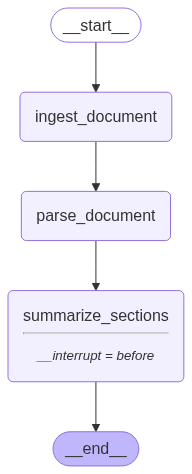

In [12]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
initial_input = {"document": ""}
config = {"configurable": {"thread_id": "1"}}

for event in graph.stream(initial_input, config, stream_mode="values"):
    print(event)

{'document': '', 'parsed_sections': ['LangGraph helps build stateful LLM agents using graphs']}
{'document': 'LangGraph helps build stateful LLM agents using graphs.', 'parsed_sections': ['LangGraph helps build stateful LLM agents using graphs']}
{'document': 'LangGraph helps build stateful LLM agents using graphs.', 'parsed_sections': ['LangGraph helps build stateful LLM agents using graphs']}


In [18]:
print(graph.get_state(config))

StateSnapshot(values={'document': 'LangGraph helps build stateful LLM agents using graphs.', 'parsed_sections': ['LangGraph helps build stateful LLM agents using graphs']}, next=('summarize_sections',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0608c0-42e3-68d4-8007-5232676898a1'}}, metadata={'source': 'loop', 'step': 7, 'parents': {}, 'thread_id': '1'}, created_at='2025-07-14T08:24:53.031127+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0608c0-42e0-6ea4-8006-05bbf08d7254'}}, tasks=(PregelTask(id='e290b7e3-93b9-2e32-cf36-60de77ce8beb', name='summarize_sections', path=('__pregel_pull', 'summarize_sections'), error=None, interrupts=(), state=None, result=None),), interrupts=())


In [19]:
for event in graph.stream(None, config, stream_mode="values"):
    print(event)

{'document': 'LangGraph helps build stateful LLM agents using graphs.', 'parsed_sections': ['LangGraph helps build stateful LLM agents using graphs']}
{'document': 'LangGraph helps build stateful LLM agents using graphs.', 'parsed_sections': ['LangGraph helps build stateful LLM agents using graphs'], 'summary': 'Summary: 1 section(s) processed.'}


In [20]:
graph_rt = builder.compile(checkpointer=checkpointer)

config_rt = {"configurable": {"thread_id": "2"}}
input_data = {"document": ""}

In [21]:
graph_rt = builder.compile(checkpointer=checkpointer)

config_rt = {"configurable": {"thread_id": "2"}}
input_data = {"document": ""}
for event in graph_rt.stream(
    input_data,
    config=config_rt,
    interrupt_before=["summarize_sections"],
    stream_mode="values"
):
    print(event)

{'document': ''}
{'document': 'LangGraph helps build stateful LLM agents using graphs.'}
{'document': 'LangGraph helps build stateful LLM agents using graphs.', 'parsed_sections': ['LangGraph helps build stateful LLM agents using graphs']}


In [22]:
print(graph_rt.get_state(config_rt))

StateSnapshot(values={'document': 'LangGraph helps build stateful LLM agents using graphs.', 'parsed_sections': ['LangGraph helps build stateful LLM agents using graphs']}, next=('summarize_sections',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0608d9-c41a-64fc-8002-8784d7ea8226'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}, 'thread_id': '2'}, created_at='2025-07-14T08:36:17.668833+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0608d9-c419-617e-8001-6c4ff70a0577'}}, tasks=(PregelTask(id='205ec63c-a0ca-bcc8-834d-4a844d25df02', name='summarize_sections', path=('__pregel_pull', 'summarize_sections'), error=None, interrupts=(), state=None, result=None),), interrupts=())


In [23]:
for event in graph_rt.stream(None, config_rt, stream_mode="values"):
    print(event)

{'document': 'LangGraph helps build stateful LLM agents using graphs.', 'parsed_sections': ['LangGraph helps build stateful LLM agents using graphs']}
{'document': 'LangGraph helps build stateful LLM agents using graphs.', 'parsed_sections': ['LangGraph helps build stateful LLM agents using graphs'], 'summary': 'Summary: 1 section(s) processed.'}
